In [ ]:
#Arxiv-Research
#Tools creation
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper



In [27]:
from langchain_core.tools import tool
import arxiv

client = arxiv.Client()

@tool
def arxiv_search(query: str) -> str:
    """Search for research papers on Arxiv about any topic including Physics, Mathematics, Computer Science, AI and Machine Learning."""
    search = arxiv.Search(query=query, max_results=2)
    results = []
    for paper in client.results(search):
        results.append(
            f"Title: {paper.title}\n"
            f"Summary: {paper.summary[:300]}"
        )
    return "\n---\n".join(results) if results else "No papers found."

# Test tool
print(arxiv_search.invoke("machine learning"))

Title: Changing Data Sources in the Age of Machine Learning for Official Statistics
Summary: Data science has become increasingly essential for the production of official statistics, as it enables the automated collection, processing, and analysis of large amounts of data. With such data science practices in place, it enables more timely, more insightful and more flexible reporting. However
---
Title: DOME: Recommendations for supervised machine learning validation in biology
Summary: Modern biology frequently relies on machine learning to provide predictions and improve decision processes. There have been recent calls for more scrutiny on machine learning performance and possible limitations. Here we present a set of community-wide recommendations aiming to help establish standa


In [28]:
#Custom tools
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter



c:\Users\jhasu\OneDrive\Desktop\LangChain\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [29]:
loader=WebBaseLoader("https://docs.smith.langchain.com/")
docs=loader.load()
docs

[Document(metadata={'source': 'https://docs.smith.langchain.com/', 'title': 'LangSmith Observability - Docs by LangChain', 'description': 'Instrument your LLM application, investigate traces, and monitor performance in production with LangSmith.', 'language': 'en'}, page_content='LangSmith Observability - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentJoin our product experts for a "Build More with LangSmith: Summer AMA Series" from July 9-August 12, 2026. RSVP todayDocs by LangChain home pageMonitorSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangSmith ObservabilityOverviewEngineTraceDebugObserveLangSmith ObservabilityLangSmith Observability provides full visibility into your LLM application: from individual traces to production-wide performance metrics.LangSmith works with many frameworks and providers. Browse available integration

In [30]:
documents=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200).split_documents(docs)
vectordb=FAISS.from_documents(documents,HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2"))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1434.82it/s]


In [31]:
retriever=vectordb.as_retriever()

In [32]:
from langchain_core.tools.retriever import create_retriever_tool
retriever_tool=create_retriever_tool(
    retriever,
    "langsmith-search",
    "Search any information about Langsmith"
)
retriever_tool.name

'langsmith-search'

In [33]:
tools=[retriever_tool,arxiv_search]

In [34]:
#Tools-> LLM,AgentExecutor

import os
from dotenv import load_dotenv
load_dotenv()

groq_api_key=os.getenv("GROQ_API_KEY")

from langchain_groq import ChatGroq

llm=ChatGroq(api_key=groq_api_key,model_name="llama-3.1-8b-instant")
test=llm.invoke("Say hello")
test.content


'Hello. How can I assist you today?'

In [36]:
from langchain_core.prompts import PromptTemplate,SystemMessagePromptTemplate,HumanMessagePromptTemplate,MessagesPlaceholder,ChatPromptTemplate

prompt=ChatPromptTemplate.from_messages(
    [
    SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[],template='You are a helpful assistant')),
    MessagesPlaceholder("chat_history", optional=True),  # memory
    HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'],template='{input}')),
    MessagesPlaceholder("agent_scratchpad"),              # agent thinking steps
]

)

C:\Users\jhasu\AppData\Local\Temp\ipykernel_26668\1784578938.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent=create_react_agent(model=llm,tools=tools)


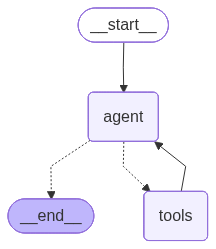

In [35]:
from langgraph.prebuilt import create_react_agent

agent=create_react_agent(model=llm,tools=tools)
agent

In [36]:

from langchain_core.messages import HumanMessage
response = agent.invoke({
    "messages": [HumanMessage(content="What is LangSmith?")]
})

print(response["messages"][-1].content)

The LangSmith platform is a comprehensive suite of tools for building, deploying, and managing large language models (LLMs). It offers a range of features, including observability, evaluation, prompt engineering, and deployment, which are not typically found in other LLM platforms. While other platforms, such as OpenAI, Anthropic, and CrewAI, offer some of these features, LangSmith's unique combination of capabilities makes it a compelling choice for developers and organizations seeking to build and deploy sophisticated LLMs.

In terms of pricing, LangSmith's platform setup offers a range of options, including cloud, hybrid, and self-hosted deployment. This flexibility allows users to choose the best option for their specific needs and budget. Additionally, LangSmith's pricing model is designed to be transparent and predictable, with no hidden fees or surprises.

When compared to other LLM platforms, LangSmith stands out for its comprehensive set of features and its focus on observabil

In [37]:
# See full agent reasoning — which tools it called
for message in response["messages"]:
    print(type(message).__name__, "→", message.content[:100])
    print("---")

HumanMessage → What is LangSmith?
---
AIMessage → 
---
ToolMessage → LangSmith Observability - Docs by LangChainDocumentation IndexFetch the complete documentation index
---
AIMessage → 
---
ToolMessage → cause, and resolve them with LangSmith Engine.For terminology and core concepts, refer to Observabil
---
AIMessage → 
---
ToolMessage → LangSmith Observability - Docs by LangChainDocumentation IndexFetch the complete documentation index
---
AIMessage → 
---
ToolMessage → cause, and resolve them with LangSmith Engine.For terminology and core concepts, refer to Observabil
---
AIMessage → 
---
ToolMessage → cause, and resolve them with LangSmith Engine.For terminology and core concepts, refer to Observabil
---
AIMessage → 
---
ToolMessage → LangSmith Observability - Docs by LangChainDocumentation IndexFetch the complete documentation index
---
AIMessage → 
---
ToolMessage → LangSmith Observability - Docs by LangChainDocumentation IndexFetch the complete documentation index
---
AIMessage 